# NinjaOne Overview

# Library

In [1]:
from graphviz import Digraph

# Configuration

In [2]:
FONT = "Helvetica"

# ---- Colours: accent (border / edge / font) and *_BG (fill) pairs ----
BLUE, GREEN, PINK = "#4a7fb5", "#4c8c4f", "#e91e63"          # Helpdesk / Managed Service team / ITOC
BLUE_BG, GREEN_BG, PINK_BG = "#e3f0ff", "#e8f5e9", "#fce4ec"  # fills for the team nodes above
P_PC, P_PC_BG = "#c8891f", "#fdf0d5"                # Company-wide PC Policy
P_OV, P_OV_BG = "#2a8a8a", "#e2f2f2"                # Office B PC Policy
P_SRV, P_SRV_BG = "#7b5ea7", "#f1ebfa"              # Company-wide Server Policy
LOC, LOC_BG = "#8a6d3b", "#fdf8ef"                  # Locations

# Graph-wide defaults
NODE_BG = "#ffffff"                                 # default node fill (white)
NODE_BORDER = "grey50"                              # default node border
EDGE = "grey35"                                     # default edge colour

# Clusters
VND, VND_BG = "grey40", "#f5f5f5"                   # VENDOR (teams) cluster
NINJA, NINJA_BG = "grey30", "#fafafa"               # NinjaOne cluster
RELAY = "grey45"                                    # Remote Control relay node border
RA, RA_BG = "grey45", "#f2f6fa"                     # Remote Access Settings cluster
POL_ALL, POL_ALL_BG = "grey40", "#f7f7f7"           # Policies cluster
POL_DEF, POL_DEF_BG = "grey35", "#efefef"           # Organisation default policies cluster
CUST, CUST_BG = "grey30", "#fbfbfb"                 # CUSTOMER (estate) cluster
OFFICE, OFFICE_BG = "#6f8f6f", "#eef3ee"            # Office A/B/C clusters and their devices

In [3]:
VENDOR = "VENDOR"
CUSTOMER = "CUSTOMER"
MONITORING = "MONITORING TEAM"
HELPDESK = "HELPDESK TEAM"
ENGINEER = "ENGINEER TEAM"

# Diagram

In [4]:
g = Digraph(
    "ninjaone_concept",
    graph_attr={
        "rankdir": "LR", "compound": "true", "splines": "spline",
        "nodesep": "0.35", "ranksep": "0.9", "fontname": FONT,
        "labelloc": "t", "fontsize": "18", "pad": "0.4",
        "label": "NinjaOne — Overview",
    },
    node_attr={"fontname": FONT, "fontsize": "11", "shape": "box", "style": "filled",
               "fillcolor": NODE_BG, "color": NODE_BORDER, "margin": "0.16,0.09"},
    edge_attr={"fontname": FONT, "fontsize": "10", "color": EDGE},
)

# Teams

In [5]:
with g.subgraph(name="cluster_teams") as t:
    t.attr(label=f"{VENDOR}", style="rounded,filled", fillcolor=VND_BG,
           color=VND, fontname=FONT, fontsize="13")
    t.node("itoc", f"{MONITORING}", style="filled,rounded",
           fillcolor=PINK_BG, color=PINK)
    t.node("helpdesk", f"{HELPDESK}", style="filled,rounded",
           fillcolor=BLUE_BG, color=BLUE)
    t.node("se", f"{ENGINEER}", style="filled,rounded",
           fillcolor=GREEN_BG, color=GREEN)

# Platform

In [6]:
with g.subgraph(name="cluster_ninja") as n:
    n.attr(label="NinjaOne", style="rounded,filled", fillcolor=NINJA_BG,
           color=NINJA, fontname=FONT, fontsize="14")

    n.node("relay", "Remote Control\n(session relayed via NinjaOne cloud)",
           style="filled,rounded", fillcolor=NODE_BG, color=RELAY)

    with n.subgraph(name="cluster_ra") as ra:
        ra.attr(label="Remote Access Settings (Organisation level, per node class)",
                style="filled", fillcolor=RA_BG, color=RA,
                fontname=FONT, fontsize="11")
        ra.node("ra_ws", "Windows Workstation role\n· End-user confirmation is required",
                fillcolor=NODE_BG, color=BLUE)
        ra.node("ra_srv", "Windows Server role\n· End-user confirmation is NOT required",
                fillcolor=NODE_BG, color=GREEN)

    # every policy in the organisation lives in this box
    with n.subgraph(name="cluster_pol_all") as pa:
        pa.attr(label="Policies", style="filled",
                fillcolor=POL_ALL_BG, color=POL_ALL, fontname=FONT, fontsize="13")

        # ...of which these two are the organisation defaults
        with pa.subgraph(name="cluster_pol_default") as pd:
            pd.attr(label="Organisation default policies (per device role)",
                    style="filled", fillcolor=POL_DEF_BG, color=POL_DEF,
                    fontname=FONT, fontsize="11")
            pd.node("pol_ws",
                    "Company-wide PC Policy\nWindows patch installation and restart: Monday\n",
                    fillcolor=P_PC_BG, color=P_PC)
            pd.node("pol_srv",
                    "Company-wide Server Policy\nWindows patch installation and restart: Saturday\n"
                    "service monitoring\n"
                    "log monitoring",
                    fillcolor=P_SRV_BG, color=P_SRV)

        pa.node("pol_ov",
                "Office B PC Policy\nWindows patch installation and restart: Wednesday",
                fillcolor=P_OV_BG, color=P_OV)

    # locations
    with n.subgraph(name="cluster_loc") as l:
        l.attr(label="Locations", style="filled",
               fillcolor=LOC_BG, color=LOC, fontname=FONT, fontsize="12")
        l.node("loc_a", "Office A\n· Policy location override: OFF\n"
                        "-> inherits both organisation defaults",
               fillcolor=NODE_BG, color=LOC)
        l.node("loc_b", "Office B\n· Policy location override: OFF\n"
                        "-> inherits both organisation defaults\n"
                        "  (server policy assigned, no server devices yet)",
               fillcolor=NODE_BG, color=LOC)
        l.node("loc_c", "Office C\n· Policy location override: ON\n"
                        "-> defaults do NOT apply; selected explicitly:\n"
                        "  Workstation role = Office B PC Policy\n"
                        "  Server role = Company-wide Server Policy",
               fillcolor=P_OV_BG, color=P_OV)

# Estate

In [7]:
with g.subgraph(name="cluster_estate") as e:
    e.attr(label=f"{CUSTOMER}", style="rounded,filled", fillcolor=CUST_BG, color=CUST, fontname=FONT, fontsize="14")

    with e.subgraph(name="cluster_a") as a:
        a.attr(label="Office A", style="filled", fillcolor=OFFICE_BG, color=OFFICE, fontname=FONT, fontsize="12")
        a.node("pc_a", "Windows 11 Pro", fillcolor=NODE_BG, color=OFFICE)
        a.node("srv_a", "Windows Servers 2025", shape="box3d", fillcolor=NODE_BG, color=OFFICE)

    with e.subgraph(name="cluster_b") as b:
        b.attr(label="Office B", style="filled", fillcolor=OFFICE_BG, color=OFFICE, fontname=FONT, fontsize="12")
        b.node("pc_b", "Windows 11 Pro", fillcolor=NODE_BG, color=OFFICE)

    with e.subgraph(name="cluster_c") as c:
        c.attr(label="Office C", style="filled", fillcolor=OFFICE_BG, color=OFFICE, fontname=FONT, fontsize="12")
        c.node("pc_c", "Windows 11 Pro", fillcolor=NODE_BG, color=OFFICE)
        c.node("srv_c", "Windows server 2022", shape="box3d",
               fillcolor=NODE_BG, color=OFFICE)

# Edge

## Policy -> Location

In [8]:
g.edge("pol_ws", "loc_a", label="default applies", style="dashed", color=P_PC, fontcolor=P_PC)
g.edge("pol_srv", "loc_a", label="default applies", style="dashed", color=P_SRV, fontcolor=P_SRV)
g.edge("pol_ws", "loc_b", label="default applies", style="dashed", color=P_PC, fontcolor=P_PC)
g.edge("pol_srv", "loc_b", label="default applies", style="dashed", color=P_SRV, fontcolor=P_SRV)
g.edge("pol_ov", "loc_c", label="selected by override", style="dashed", color=P_OV, fontcolor=P_OV, penwidth="1.6")
g.edge("pol_srv", "loc_c", label="selected by override", style="dashed", color=P_SRV, fontcolor=P_SRV, penwidth="1.6")

## location -> devices (edge colour = policy actually in effect)

In [9]:
g.edge("loc_a", "pc_a", label="default PC policy in effect", color=P_PC, fontcolor=P_PC)
g.edge("loc_a", "srv_a", label="default Server policy in effect", color=P_SRV, fontcolor=P_SRV)
g.edge("loc_b", "pc_b", label="default PC policy in effect", color=P_PC, fontcolor=P_PC)
g.edge("loc_c", "pc_c", label="Office B PC policy in effect", color=P_OV,fontcolor=P_OV, penwidth="1.8")
g.edge("loc_c", "srv_c", label="defaultServer policy in effect", color=P_SRV, fontcolor=P_SRV)

## system monitoring

In [10]:
g.edge("srv_a", "itoc", label="service stop alert", color=PINK, fontcolor=PINK)
g.edge("srv_c", "itoc", label="error log alert", color=PINK, fontcolor=PINK)

## remote access path

In [11]:
g.edge("helpdesk", "relay", label="remote session (PCs)", color=BLUE, fontcolor=BLUE)
g.edge("se", "relay", label="remote session (Servers)", color=GREEN, fontcolor=GREEN)
g.edge("relay", "ra_ws", color=BLUE)
g.edge("relay", "ra_srv", color=GREEN)

for tgt in ("pc_a", "pc_b", "pc_c"):
    g.edge("ra_ws", tgt, label="remote access", color=BLUE, fontcolor=BLUE)
for tgt in ("srv_a", "srv_c"):
    g.edge("ra_srv", tgt, label="remote access", color=GREEN, fontcolor=GREEN)

# Display Result

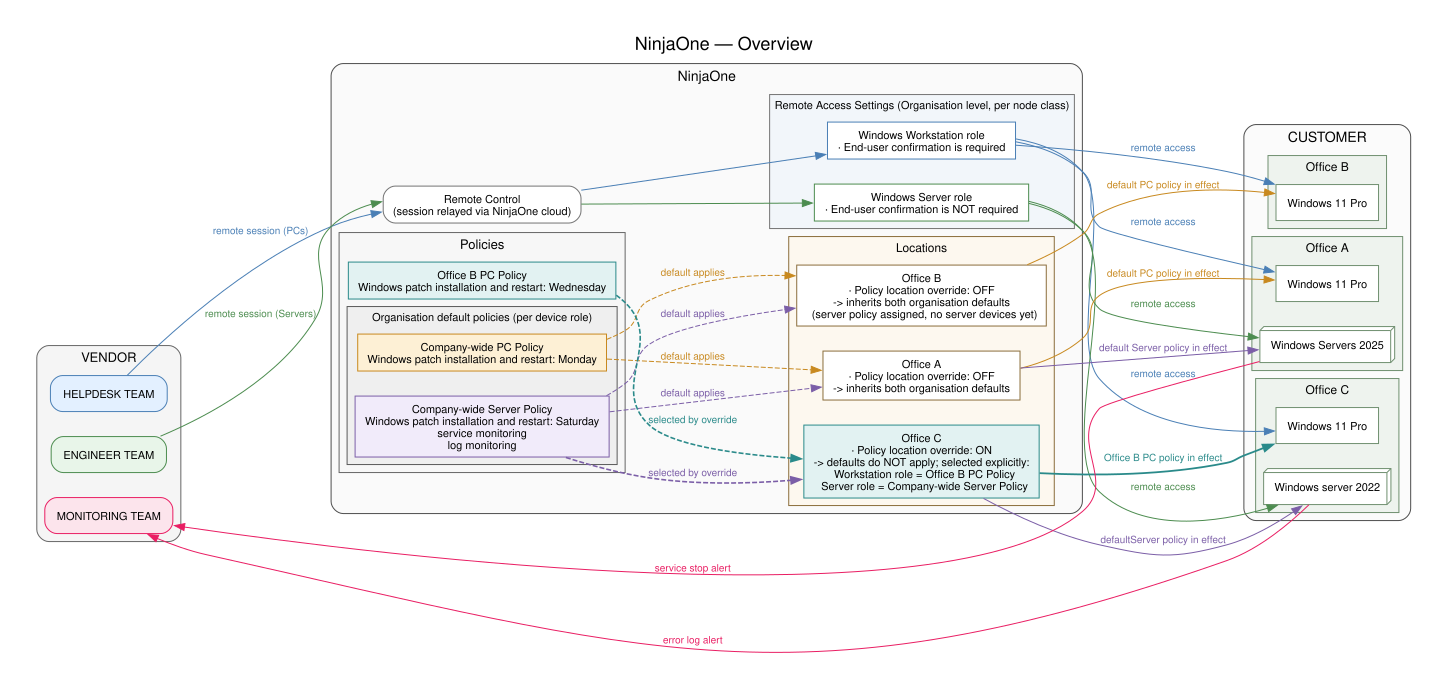

In [12]:
g

In [13]:
g.render("ninjaone_concept", format="svg", cleanup=True)
g.render("ninjaone_concept", format="png", cleanup=True)

'ninjaone_concept.png'